# DINO Frozen Backbone — Sonuç Raporu

Bu notebook, `dino_feature_eval.py` ile üretilen ve `features/{model_adı}/` altında cache'lenen CLS-token özellikleri üzerinden k-NN ve linear probe sonuçlarını yükler, karşılaştırmalı bir tablo ve grafik olarak sunar.

Yeni bir model çalıştırdıktan sonra (`python dino_feature_eval.py --model ...`), sadece `MODELS` listesine ekleyip notebook'u yeniden çalıştırman yeterli.

In [1]:
import json
import os

import pandas as pd

from dino_feature_eval import knn_eval, linear_probe_eval, load_cached_features, sanitize_model_name

FEATURES_DIR = "features"
KNN_K = 20

MODELS = [
    "facebook/dinov2-small",
    "facebook/dinov2-base",
    "facebook/dinov3-vits16-pretrain-lvd1689m",
]

C:\Users\Sümeyye\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_results(model_name: str, features_dir: str = FEATURES_DIR, k: int = KNN_K):
    model_dir = os.path.join(features_dir, sanitize_model_name(model_name))
    meta_path = os.path.join(model_dir, "meta.json")
    if not os.path.exists(meta_path):
        return None

    train_feats, train_labels = load_cached_features(features_dir, model_name, "train")
    test_feats, test_labels = load_cached_features(features_dir, model_name, "test")
    if train_feats is None or test_feats is None:
        return None

    with open(meta_path) as f:
        meta = json.load(f)

    knn_acc = knn_eval(train_feats, train_labels, test_feats, test_labels, k=k)
    lp_acc = linear_probe_eval(train_feats, train_labels, test_feats, test_labels)

    return {
        "model": model_name,
        "feature_dim": meta["feature_dim"],
        "train_samples": meta["num_samples"]["train"],
        "test_samples": meta["num_samples"]["test"],
        f"knn_k{k}_acc": knn_acc,
        "linear_probe_acc": lp_acc,
    }


results_by_model = {m: load_results(m) for m in MODELS}
missing = [m for m, r in results_by_model.items() if r is None]
if missing:
    print("Henüz cache'i olmayan modeller (atlandı):", missing)

results_df = pd.DataFrame([r for r in results_by_model.values() if r is not None]).set_index("model")
results_df

Henüz cache'i olmayan modeller (atlandı): ['facebook/dinov3-vits16-pretrain-lvd1689m']


,feature_dim,train_samples,test_samples,knn_k20_acc,linear_probe_acc
model,,,,,
facebook/dinov2-small,384,50000,10000,0.9448,0.9486
facebook/dinov2-base,768,50000,10000,0.9797,0.9758


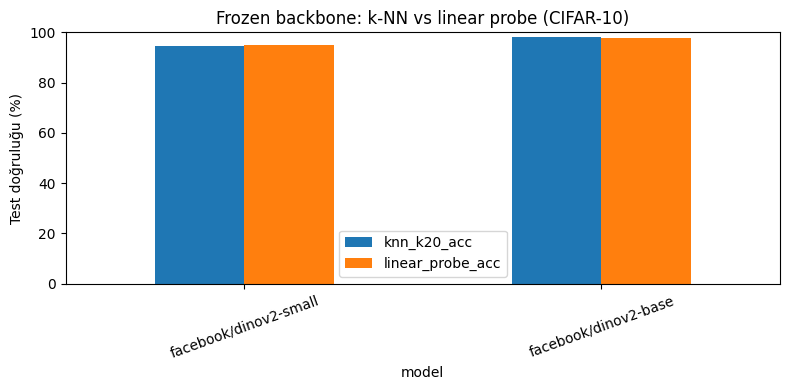

In [3]:
import matplotlib.pyplot as plt

acc_cols = [c for c in results_df.columns if c.endswith("_acc")]
ax = (results_df[acc_cols] * 100).plot.bar(figsize=(8, 4), rot=20)
ax.set_ylabel("Test doğruluğu (%)")
ax.set_ylim(0, 100)
ax.set_title("Frozen backbone: k-NN vs linear probe (CIFAR-10)")
ax.legend(title="")
plt.tight_layout()
plt.show()

## Not

Bu sayılar, dondurulmuş (fine-tune edilmemiş) backbone'lardan çıkarılan CLS-token özellikleri üzerinde k-NN ve linear probe ile elde edildi. Önceki çalışmadaki fine-tuned ViT-B/16 vs Swin-T sonuçlarıyla karşılaştırma yapılacaksa, o rakamlar buraya ayrı bir tabloda eklenmeli.